In [2]:
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torchvision.utils as vutils
from PIL import Image  

In [3]:
# Constants
DATA_DIR = 'data'
SAVE_PATH = 'preprocessed_data_forGAN.npz'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = (64, 64)
IMG_DIR_NAMES = ['wiki', 'inpainting', 'insight', 'text2img']
REAL_IMG_DIR = 'wiki'

In [4]:
def isImgFake(img_main_dir):
    return int(img_main_dir != REAL_IMG_DIR)

In [5]:
# Loading of the images and preprocessing
def load_and_preprocess_images(data_dir, img_size, save_path):
    """
    Loads and preprocesses images from the specified directory.
    Saves the preprocessed data to a file to avoid reprocessing.
    """
    # Check if preprocessed data already exists
    if os.path.exists(save_path):
        print(f"Loading preprocessed data from {save_path}...")
        data = np.load(save_path)
        return data['X'], data['y']
    
    print(f"Loading and preprocessing images from {data_dir}...")
    X = []
    y = []
    
    for index, main_folder in enumerate(IMG_DIR_NAMES):
        main_folder_path = os.path.join(data_dir, main_folder)
        print(f"Processing directory {main_folder}...")
        image_count = 0
        for subfolder_name in os.listdir(main_folder_path):
            subfolder_path = os.path.join(main_folder_path, subfolder_name)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.endswith('.jpg'):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            img = Image.open(img_path).convert('RGB')  # Ensure RGB format
                            img = img.resize(img_size)
                            img_array = (np.array(img) / 127.5) - 1.0  # Normalize to [-1, 1]
                            X.append(img_array)
                            y.append(isImgFake(main_folder))  # 1 for other, 0 for wiki
                            image_count += 1
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
                    else:
                        print(f"Skipping non jpg file: {filename}")
                        
        print(f"  - Loaded {image_count} images for category {main_folder}")

    print(f"Total images loaded: {len(X)}")
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    print(X)
    print(y)
    
    # Save preprocessed data
    print(f"Saving preprocessed data to {save_path}...")
    np.savez(save_path, X=X, y=y)
    
    return X, y

In [6]:
print("\n--- Starting Image Classification ---")

# Ensure the data directory exists
if not os.path.exists(DATA_DIR):
	os.makedirs(DATA_DIR)
	for dir_name in IMG_DIR_NAMES:
		os.makedirs(os.path.join(DATA_DIR, dir_name))

# Load and preprocess data
X, y = load_and_preprocess_images(DATA_DIR, IMG_SIZE, SAVE_PATH)

# Split the data
print("\nSplitting data into training and testing sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)  # Change shape to [batch, channels, height, width]
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape for BCE loss
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)



--- Starting Image Classification ---
Loading preprocessed data from preprocessed_data_forGAN.npz...

Splitting data into training and testing sets (80/20)...


In [7]:
class Generator(nn.Module):
    """Generates artificial images form a random vector as input.
    """

    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            ## Deconvolution layer(vector size, size of feature maps, kernel size, stride, padding, bias)
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input_vector):
        return self.main(input_vector)


class Discriminator(nn.Module):
    """Evaluates the artificial images from the Generator and
    either accepts or rejects the image (returns value between 0 - 1).
    """

    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input_image):
        return self.main(input_image).view(-1)

In [8]:
# Parameters
batch_size = 64
latent_dim = 100
num_epochs = 25
lr = 2e-4
beta1 = 0.5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize weights
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create directory for results
if not os.path.exists('results'):
    os.makedirs('results')
if not os.path.exists('models'):
    os.makedirs('models')

Generator:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Ta

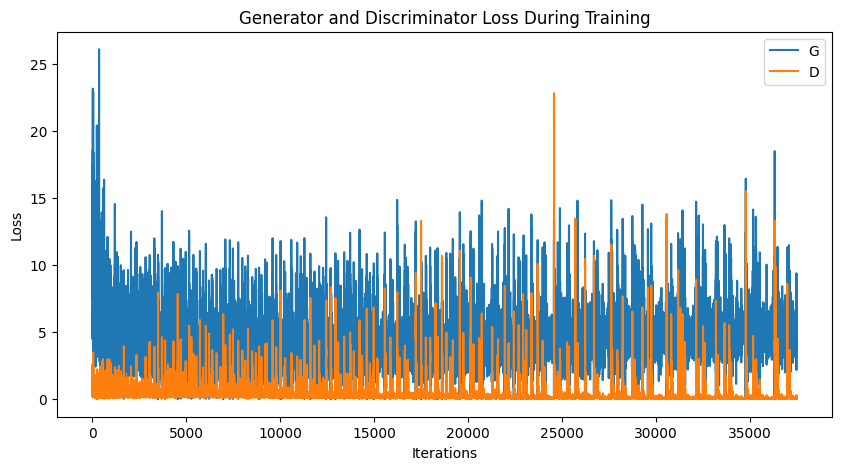

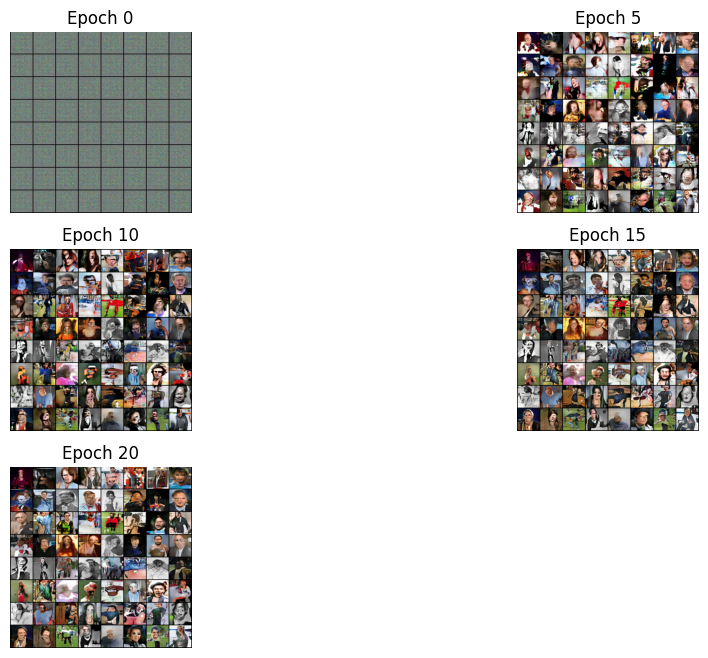

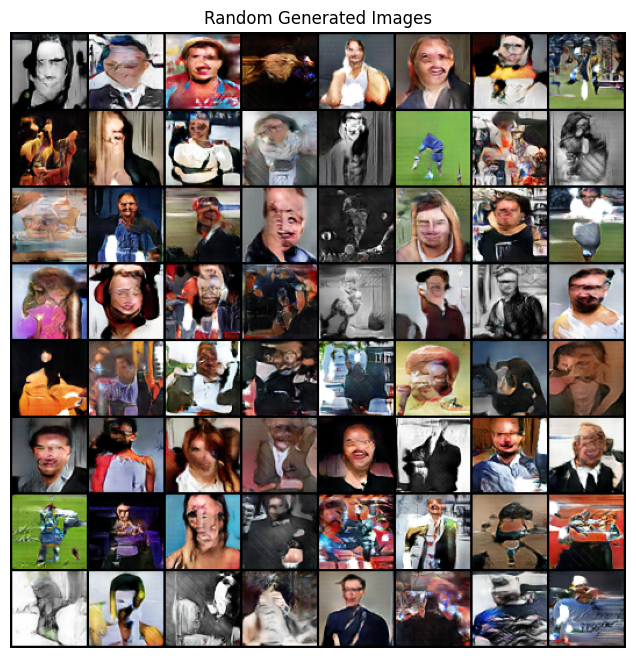

Training complete!


In [9]:
# Create instances and initialize weights
netG = Generator().to(device).apply(weights_init)
netD = Discriminator().to(device).apply(weights_init)

print("Generator:")
print(netG)
print("\nDiscriminator:")
print(netD)

# Setup optimizers
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Loss function
criterion = nn.BCELoss()

# Create fixed noise for visualization
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

# For tracking progress
real_label = 1.0
fake_label = 0.0
img_list = []
G_losses = []
D_losses = []

# Training Loop
print("Starting Training...")
for epoch in range(num_epochs):
    for i, (data, _) in enumerate(train_loader):
        # Move data to device
        real_imgs = data.to(device)
        batch_size = real_imgs.size(0)
        
        # Create labels
        real_labels = torch.full((batch_size,), real_label, device=device)
        fake_labels = torch.full((batch_size,), fake_label, device=device)
        
        #############################
        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        #############################
        netD.zero_grad()
        
        # Train with real images
        output = netD(real_imgs)
        errD_real = criterion(output, real_labels)
        errD_real.backward()
        D_x = output.mean().item()
        
        # Train with fake images
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake = netG(noise)
        output = netD(fake.detach())
        errD_fake = criterion(output, fake_labels)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        # Add gradients from all-real and all-fake batches
        errD = errD_real + errD_fake
        optimizerD.step()
        
        #############################
        # (2) Update Generator: maximize log(D(G(z)))
        #############################
        netG.zero_grad()
        output = netD(fake)  # D's output for fake images
        # Generator wants D to think these are real
        errG = criterion(output, real_labels)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        
        # Track losses
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(train_loader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')
            
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        
        # Save sample images every 100 batches
        if (epoch == 0 or epoch % 5 == 0) and i == 0:
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))
            
            # Save images
            img_name = f'fake_samples_epoch_{epoch:03d}.png'
            img_path = os.path.join('./results', img_name)
            vutils.save_image(fake, img_path, normalize=True)
    
    # Save models after each epoch
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        torch.save({
            'epoch': epoch,
            'state_dict': netG.state_dict(),
            'optimizer': optimizerG.state_dict()
        }, f'./models/generator_epoch_{epoch}.pth')
        
        torch.save({
            'epoch': epoch,
            'state_dict': netD.state_dict(),
            'optimizer': optimizerD.state_dict()
        }, f'./models/discriminator_epoch_{epoch}.pth')

# Final visualization
# Plot losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig('./results/loss_plot.png')
plt.show()

# Plot sample images from different epochs
plt.figure(figsize=(12, 8))
for i, img in enumerate(img_list):
    plt.subplot(3, len(img_list)//3 + 1, i+1)
    plt.axis("off")
    plt.title(f"Epoch {i*5}")
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.savefig('./results/generation_progress.png')
plt.show()

# Generate and display random samples
with torch.no_grad():
    noise = torch.randn(64, latent_dim, 1, 1, device=device)
    fake = netG(noise).detach().cpu()
    
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Random Generated Images")
plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
plt.savefig('./results/final_samples.png')
plt.show()

print("Training complete!")